# 3. Algoritam k-najbližih suseda (k-NN)

## Modeli zasnovani na instancama

kNN je **neparametarski** algoritam i spada u **metode zasnovane na instancama**
(memorijske metode).

- sve instance iz trening skupa se čuvaju u memoriji
- **ne postoji eksplicitna faza učenja** — otud naziv *lazy learning*
- predikcija se računa tek kada stigne nova instanca

## Princip rada

1. Izabrati broj suseda $k$
2. Izabrati meru udaljenosti
3. Za novu instancu izračunati udaljenost do **svih** trening instanci
4. Izabrati $k$ najbližih
5. Doneti odluku:
   - **klasifikacija** — većinsko glasanje
   - **regresija** — srednja vrednost (ili ponderisani prosek) suseda

> Osnovna ideja: **slični podaci imaju slične izlaze.** kNN pravi **lokalne** odluke,
> umesto globalnog modela.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris, make_moons
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline

plt.rcParams["figure.figsize"] = (9, 4.5); plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True; plt.rcParams["grid.alpha"] = 0.3
RS = 42

X, y = make_moons(n_samples=300, noise=0.28, random_state=RS)
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=RS, stratify=y)
print(f"Podaci: {X.shape[0]} uzoraka, 2 obelezja, 2 klase")

Podaci: 300 uzoraka, 2 obelezja, 2 klase


## Izbor parametra $k$

$k$ je **hiperparametar** — određuje koliko suseda učestvuje u odluci i time kontroliše
složenost modela.

| $k$ | granica odlučivanja | bias / varijansa | posledica |
|---|---|---|---|
| **malo** ($k=1$) | vrlo neregularna | **nizak bias, visoka varijansa** | osetljiv na šum, **overfitting** |
| **srednje** ($k \approx 10$) | uravnotežena | dobar kompromis | najbolje |
| **veliko** ($k=50+$) | vrlo glatka | **visok bias, niska varijansa** | gubi lokalnu strukturu, **underfitting** |

Bira se **eksperimentalno** — validacionim skupom ili kros-validacijom. Kod klasifikacije
se često bira **neparan** $k$ da bi se izbegao nerešen ishod pri glasanju.

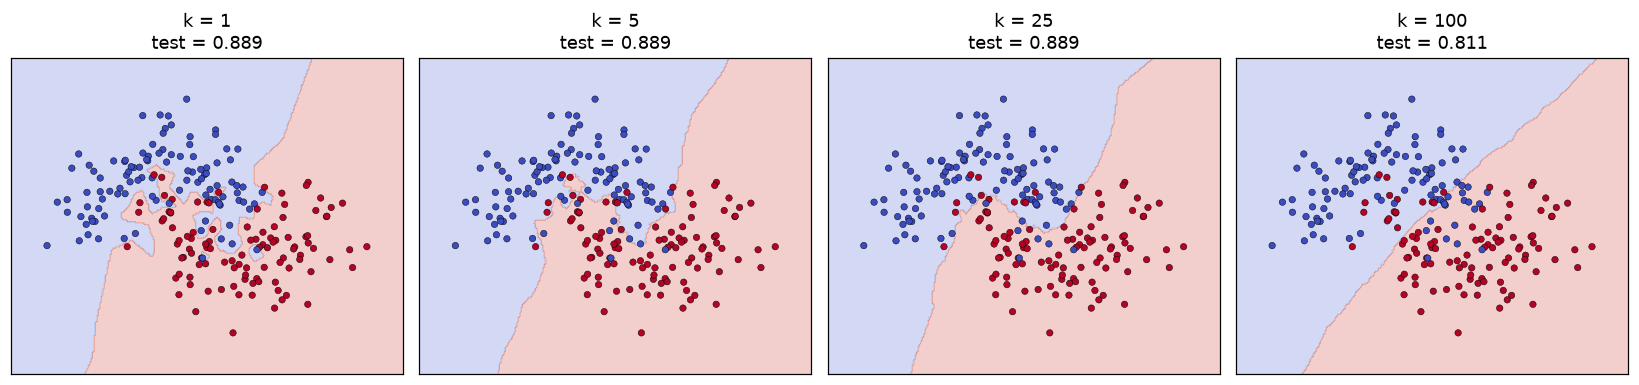

k=1  : granica prati svaku tacku -> overfitting
k=100: granica je skoro prava    -> underfitting


In [2]:
def granica(ax, model, X, y, naslov):
    h = 0.02
    x0, x1 = X[:, 0].min() - .5, X[:, 0].max() + .5
    y0, y1 = X[:, 1].min() - .5, X[:, 1].max() + .5
    xx, yy = np.meshgrid(np.arange(x0, x1, h), np.arange(y0, y1, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap="coolwarm")
    ax.scatter(X[:, 0], X[:, 1], c=y, s=18, cmap="coolwarm", edgecolor="k", linewidth=0.3)
    ax.set_title(naslov); ax.set_xticks([]); ax.set_yticks([])

fig, ax = plt.subplots(1, 4, figsize=(15, 3.6))
for a, k in zip(ax, (1, 5, 25, 100)):
    m = KNeighborsClassifier(n_neighbors=k).fit(Xtr, ytr)
    granica(a, m, Xtr, ytr, f"k = {k}\ntest = {m.score(Xte, yte):.3f}")
plt.tight_layout(); plt.show()
print("k=1  : granica prati svaku tacku -> overfitting")
print("k=100: granica je skoro prava    -> underfitting")

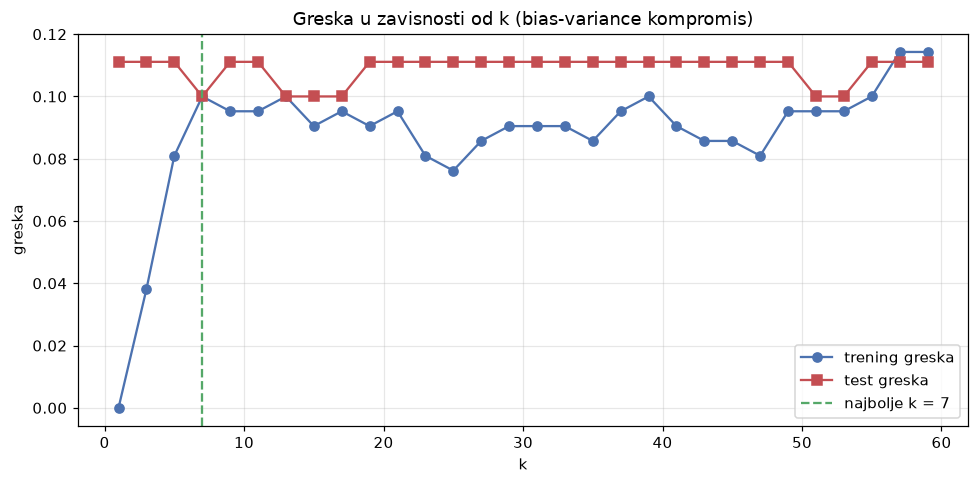

Sa smanjenjem k trening greska kontinuirano opada (k=1 -> greska 0).
Test greska ima MINIMUM na srednjem k = 7, pa raste -> overfitting.


In [3]:
ks = range(1, 61, 2)
tr, te = [], []
for k in ks:
    m = KNeighborsClassifier(n_neighbors=k).fit(Xtr, ytr)
    tr.append(1 - m.score(Xtr, ytr))
    te.append(1 - m.score(Xte, yte))

fig, ax = plt.subplots()
ax.plot(list(ks), tr, "o-", label="trening greska", color="#4C72B0")
ax.plot(list(ks), te, "s-", label="test greska", color="#C44E52")
najbolje = list(ks)[int(np.argmin(te))]
ax.axvline(najbolje, color="#55A868", ls="--", label=f"najbolje k = {najbolje}")
ax.set_xlabel("k"); ax.set_ylabel("greska")
ax.set_title("Greska u zavisnosti od k (bias-variance kompromis)")
ax.legend(); plt.tight_layout(); plt.show()

print("Sa smanjenjem k trening greska kontinuirano opada (k=1 -> greska 0).")
print(f"Test greska ima MINIMUM na srednjem k = {najbolje}, pa raste -> overfitting.")

## Mere rastojanja

kNN se zasniva na merenju sličnosti. Najčešće mere:

**Euklidsko rastojanje** (L2) — „pravolinijsko", najčešće korišćeno:

$$d(x, y) = \sqrt{\sum_{i=1}^{n}(x_i - y_i)^2}$$

**Manhattan rastojanje** (L1) — zbir apsolutnih razlika, robusnije na autlajere:

$$d(x, y) = \sum_{i=1}^{n} \lvert x_i - y_i \rvert$$

**Minkowski rastojanje** — opšti oblik:

$$d(x, y) = \left(\sum_{i=1}^{n} \lvert x_i - y_i \rvert^{p}\right)^{1/p}$$

Za $p = 1$ dobija se Manhattan, za $p = 2$ Euklidsko.

In [4]:
a = np.array([170, 25]); b = np.array([180, 30])
print(f"Tacka A = {a},  tacka B = {b}\n")
print(f"Euklidsko (p=2) : {np.sqrt(np.sum((a-b)**2)):.4f}")
print(f"Manhattan (p=1) : {np.sum(np.abs(a-b)):.4f}")
for p in (1, 2, 3, 10):
    print(f"Minkowski p={p:<3}: {np.sum(np.abs(a-b)**p)**(1/p):.4f}")

Tacka A = [170  25],  tacka B = [180  30]

Euklidsko (p=2) : 11.1803
Manhattan (p=1) : 15.0000
Minkowski p=1  : 15.0000
Minkowski p=2  : 11.1803
Minkowski p=3  : 10.4004
Minkowski p=10 : 10.0010


## Skaliranje podataka

Euklidsko rastojanje je **osetljivo na skalu**. Atributi sa većim numeričkim vrednostima
dominiraju u računanju rastojanja, čak i ako nisu važniji.

**Primer:** visina u cm (160–190) i godine (20–40).

$$d = \sqrt{(170-180)^2 + (25-30)^2} = \sqrt{100 + 25}$$

Visina doprinosi sa 100, godine sa 25 — **četiri puta veći uticaj**, iako nisu četiri puta
važnije. Rešenje je **skaliranje**.

| metoda | formula | rezultat |
|---|---|---|
| **Standardizacija** (z-score) | $x' = \dfrac{x - \mu}{\sigma}$ | srednja vrednost 0, st. devijacija 1 |
| **Min–Max** | $x' = \dfrac{x - x_{\min}}{x_{\max} - x_{\min}}$ | opseg $[0, 1]$ |

In [5]:
osobe = pd.DataFrame({"visina_cm": [170, 180, 175, 165], "godine": [25, 30, 45, 22]})
print("Doprinos svakog atributa kvadratu rastojanja A-B:")
d_v = (osobe.visina_cm[0] - osobe.visina_cm[1]) ** 2
d_g = (osobe.godine[0] - osobe.godine[1]) ** 2
print(f"   visina: {d_v}   godine: {d_g}   -> odnos {d_v/d_g:.1f} : 1\n")

z = StandardScaler().fit_transform(osobe)
mm = MinMaxScaler().fit_transform(osobe)
d_vz = (z[0, 0] - z[1, 0]) ** 2; d_gz = (z[0, 1] - z[1, 1]) ** 2
print(f"Posle standardizacije: visina {d_vz:.3f}, godine {d_gz:.3f} -> odnos {d_vz/d_gz:.2f} : 1")
print("\nz-score:"); display(pd.DataFrame(z, columns=osobe.columns).round(3))

Doprinos svakog atributa kvadratu rastojanja A-B:
   visina: 100   godine: 25   -> odnos 4.0 : 1

Posle standardizacije: visina 3.200, godine 0.319 -> odnos 10.02 : 1

z-score:


,visina_cm,godine
0,-0.447,-0.622
1,1.342,-0.057
2,0.447,1.639
3,-1.342,-0.961


### Kada se radi skaliranje — ispravan redosled

1. **Podela** podataka na trening i test
2. Skaliranje se **uči SAMO na trening skupu** (`fit`)
3. Ista transformacija se primenjuje na oba skupa (`transform`)

> **Zašto ne pre podele?** Ako skaliramo pre podele, koristimo informacije iz test skupa
> (njegovu srednju vrednost i devijaciju) → **data leakage** → nerealno dobra tačnost.

Najsigurniji način je `Pipeline`, koji sam pazi na redosled unutar kros-validacije.

In [6]:
from sklearn.datasets import load_wine
Xw, yw = load_wine(return_X_y=True)

# POGRESNO — skaliranje pre podele
sc = StandardScaler()
Xw_sve = sc.fit_transform(Xw)                    # koristi i test podatke!
a, b, c, d = train_test_split(Xw_sve, yw, test_size=0.3, random_state=RS, stratify=yw)
lose = KNeighborsClassifier(5).fit(a, c).score(b, d)

# ISPRAVNO — prvo podela, pa fit samo na treningu
a2, b2, c2, d2 = train_test_split(Xw, yw, test_size=0.3, random_state=RS, stratify=yw)
sc2 = StandardScaler().fit(a2)
dobro = KNeighborsClassifier(5).fit(sc2.transform(a2), c2).score(sc2.transform(b2), d2)

# NAJBOLJE — Pipeline
pipe = Pipeline([("sc", StandardScaler()), ("knn", KNeighborsClassifier(5))])
cv = cross_val_score(pipe, Xw, yw, cv=5)

print(f"POGRESNO (fit pre podele) : {lose:.4f}   <- data leakage")
print(f"ISPRAVNO (fit na treningu): {dobro:.4f}")
print(f"PIPELINE + 5-fold CV      : {cv.mean():.4f} +- {cv.std():.4f}")
print(f"\nBez skaliranja uopste     : {KNeighborsClassifier(5).fit(a2, c2).score(b2, d2):.4f}")

POGRESNO (fit pre podele) : 0.9444   <- data leakage
ISPRAVNO (fit na treningu): 0.9444
PIPELINE + 5-fold CV      : 0.9494 +- 0.0379

Bez skaliranja uopste     : 0.7222


## Izbor $k$ pomoću kros-validacije

In [7]:
mreza = {"knn__n_neighbors": list(range(1, 32, 2)),
         "knn__weights": ["uniform", "distance"],
         "knn__p": [1, 2]}
gs = GridSearchCV(Pipeline([("sc", StandardScaler()), ("knn", KNeighborsClassifier())]),
                  mreza, cv=5, scoring="accuracy", n_jobs=-1).fit(Xw, yw)

print(f"Najbolji parametri : {gs.best_params_}")
print(f"Najbolji CV rezultat: {gs.best_score_:.4f}")
print(f"Isprobano kombinacija: {len(gs.cv_results_['params'])}")

Najbolji parametri : {'knn__n_neighbors': 11, 'knn__p': 1, 'knn__weights': 'uniform'}
Najbolji CV rezultat: 0.9776
Isprobano kombinacija: 64


## kNN za regresiju

Isti princip, samo se umesto glasanja uzima **prosek** vrednosti $k$ suseda.

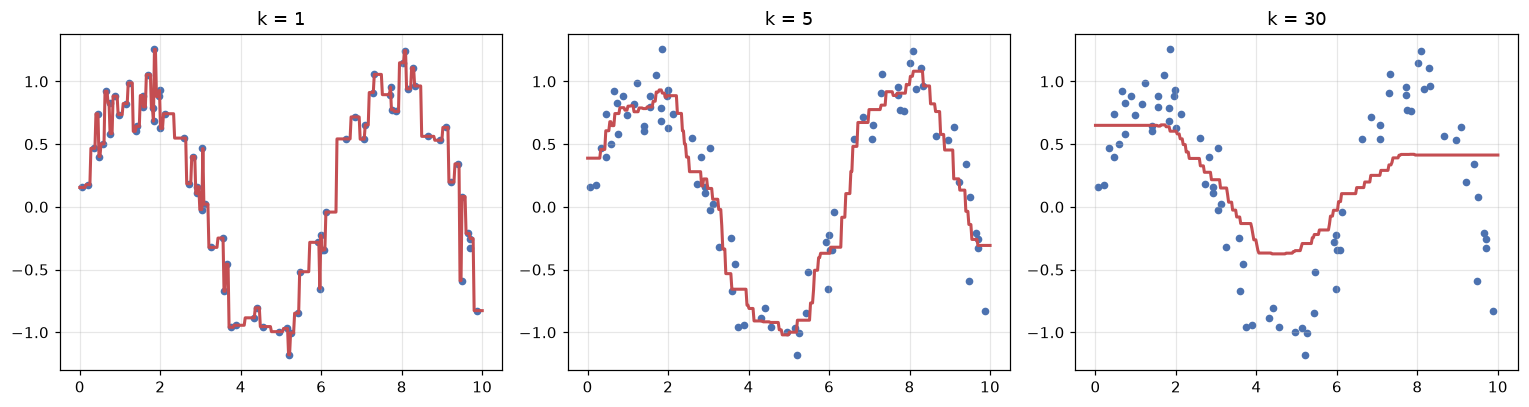

k=1: predikcija je stepenasta i prati sum. k=30: preglatka, gubi oblik sinusa.


In [8]:
Xreg = np.sort(np.random.RandomState(RS).uniform(0, 10, 80)).reshape(-1, 1)
yreg = np.sin(Xreg).ravel() + np.random.RandomState(RS).normal(0, 0.2, 80)
xx = np.linspace(0, 10, 400).reshape(-1, 1)

fig, ax = plt.subplots(1, 3, figsize=(14, 3.8))
for a, k in zip(ax, (1, 5, 30)):
    m = KNeighborsRegressor(n_neighbors=k).fit(Xreg, yreg)
    a.scatter(Xreg, yreg, s=16, color="#4C72B0")
    a.plot(xx, m.predict(xx), color="#C44E52", lw=2)
    a.set_title(f"k = {k}")
plt.tight_layout(); plt.show()
print("k=1: predikcija je stepenasta i prati sum. k=30: preglatka, gubi oblik sinusa.")

## Prednosti i nedostaci

**Prednosti**
- jednostavan i intuitivan
- nema fazu treniranja (lazy learning)
- može modelovati **nelinearne** granice odlučivanja
- dobro radi na malim i srednjim skupovima

**Nedostaci**
- **spor u fazi predikcije** — računa rastojanje do svih instanci
- veliki memorijski zahtevi
- osetljiv na izbor $k$, meru rastojanja i **skaliranje**
- slabo se ponaša u visokodimenzionalnom prostoru — **prokletstvo dimenzionalnosti**

In [9]:
from sklearn.datasets import make_classification
print("Prokletstvo dimenzionalnosti — samo 5 obelezja je informativno:\n")
print(f"{'dimenzija':>10} {'tacnost':>9}")
for d in (5, 10, 25, 50, 200, 500):
    Xd, yd = make_classification(n_samples=600, n_features=d, n_informative=5,
                                 n_redundant=0, n_repeated=0, random_state=RS)
    s = cross_val_score(Pipeline([("sc", StandardScaler()), ("knn", KNeighborsClassifier(5))]),
                        Xd, yd, cv=5).mean()
    print(f"{d:>10} {s:>9.4f}")
print("\n-> Sa rastom dimenzije sve tacke postaju priblizno jednako udaljene,")
print("   pa pojam 'najblizi sused' gubi smisao.")

Prokletstvo dimenzionalnosti — samo 5 obelezja je informativno:

 dimenzija   tacnost
         5    0.9033
        10    0.8433


        25    0.6983
        50    0.6850
       200    0.5700
       500    0.5300

-> Sa rastom dimenzije sve tacke postaju priblizno jednako udaljene,
   pa pojam 'najblizi sused' gubi smisao.
